Underfit - Acurácia treino: 0.3237867939538584
Underfit - Acurácia teste: 0.3
Overfit - Acurácia treino: 1.0
Overfit - Acurácia teste: 0.8425925925925926
Validação k-fold (5 folds): [0.975      0.96111111 0.96100279 0.96100279 0.95821727]
Média acurácia: 0.9632667904673475


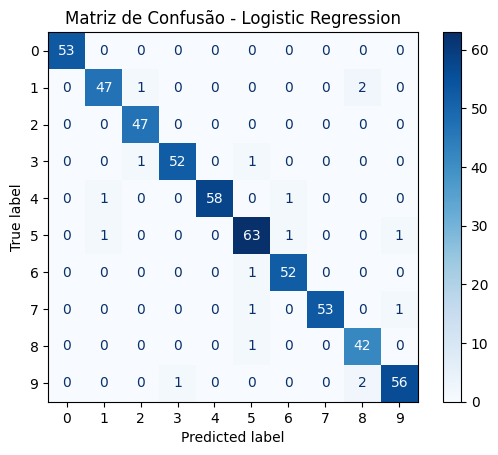

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1️⃣ Carregar dataset
digits = load_digits()
X, y = digits.data, digits.target

# 2️⃣ Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3️⃣ Modelo simples (underfit) → árvore com profundidade muito baixa
underfit_model = DecisionTreeClassifier(max_depth=2, random_state=42)
underfit_model.fit(X_train, y_train)
print("Underfit - Acurácia treino:", underfit_model.score(X_train, y_train))
print("Underfit - Acurácia teste:", underfit_model.score(X_test, y_test))

# 4️⃣ Modelo complexo (overfit) → árvore sem limite de profundidade
overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_model.fit(X_train, y_train)
print("Overfit - Acurácia treino:", overfit_model.score(X_train, y_train))
print("Overfit - Acurácia teste:", overfit_model.score(X_test, y_test))

# 5️⃣ Modelo equilibrado → regressão logística
balanced_model = LogisticRegression(max_iter=2000)
balanced_model.fit(X_train, y_train)

# 6️⃣ Validação cruzada (k-folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(balanced_model, X, y, cv=kfold)
print("Validação k-fold (5 folds):", scores)
print("Média acurácia:", scores.mean())

# 7️⃣ Matriz de confusão no conjunto de teste
y_pred = balanced_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()


SVM aplicado

Acurácia treino: 0.9714285714285714
Acurácia teste: 1.0
Validação k-fold (5 folds): [1.         1.         0.96666667 0.93333333 0.96666667]
Média acurácia: 0.9733333333333334


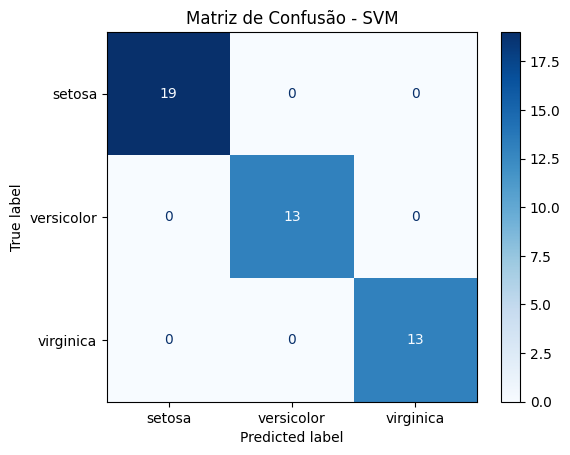

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1️⃣ Carregar dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# 2️⃣ Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3️⃣ Treinar modelo SVM
svm_model = SVC(kernel='linear')  # kernel linear para simplificar
svm_model.fit(X_train, y_train)

# 4️⃣ Avaliar desempenho
print("Acurácia treino:", svm_model.score(X_train, y_train))
print("Acurácia teste:", svm_model.score(X_test, y_test))

# 5️⃣ Validação cruzada (k-folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(svm_model, X, y, cv=kfold)
print("Validação k-fold (5 folds):", scores)
print("Média acurácia:", scores.mean())

# 6️⃣ Matriz de confusão
y_pred = svm_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - SVM")
plt.show()
